In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from tqdm import tqdm
import math
import random
import os, math, time, json, random, inspect, pickle
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt
from transformers import T5EncoderModel, T5Tokenizer
import datasets
from torch.optim.lr_scheduler import CosineAnnealingLR

/Intern/ZR/DeepSC/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import unicodedata
import re
from w3lib.html import remove_tags
import pickle
import argparse
import os
import json
from tqdm import tqdm

In [4]:
%set_env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
device

'cuda'

In [7]:
BATCH_SIZE = 32

In [8]:
#fineweb prep
from datasets import load_dataset

ds = load_dataset("Skylion007/openwebtext")

Generating train split: 100%|█████████████████████████████████████████████████████████████████████████| 8013769/8013769 [00:52<00:00, 152855.20 examples/s]


In [9]:
ds

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 8013769
    })
})

In [5]:
_SPECIAL_TOKENS = {'<PAD>', '<START>', '<END>', '<UNK>'}

In [6]:
SPECIAL_TOKENS = {
  '<PAD>': 0,
  '<START>': 1,
  '<END>': 2,
  '<UNK>': 3,
}

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    # normalize unicode characters
    s = unicode_to_ascii(s)
    # remove the XML-tags
    s = remove_tags(s)
    # add white space before !.?
    s = re.sub(r'([!.?])', r' \1', s)
    s = re.sub(r'[^a-zA-Z.!?]+', r' ', s)
    s = re.sub(r'\s+', r' ', s)
    # change to lower letter
    s = s.lower()
    return s

def cutted_data(cleaned, MIN_LENGTH=4, MAX_LENGTH=30):
    cutted_lines = list()
    for line in cleaned:
        length = len(line.split())
        if length > MIN_LENGTH and length < MAX_LENGTH:
            line = [word for word in line.split()]
            cutted_lines.append(' '.join(line))
    return cutted_lines

def save_clean_sentences(sentence, save_path):
    pickle.dump(sentence, open(save_path, 'wb'))
    print('Saved: %s' % save_path)

def process(text_path):
    fop = open(text_path, 'r', encoding='utf8')
    raw_data = fop.read()
    sentences = raw_data.strip().split('\n')
    raw_data_input = [normalize_string(data) for data in sentences]
    raw_data_input = cutted_data(raw_data_input)
    fop.close()

    return raw_data_input
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

In [7]:
sentences = []
print('Preprocess Raw Text')
for fn in tqdm(os.listdir("txt/en")):
    if not fn.endswith('.txt'):
        continue
    process_sentences = process("txt/en/" + fn)
    sentences += process_sentences

# remove the same sentences
a = {}
for set in sentences:
    if set not in a:
        a[set] = 0
    a[set] += 1
sentences = list(a.keys())
print('Number of sentences: {}'.format(len(sentences)))

Preprocess Raw Text


  0%|                                                                                                                             | 0/9672 [00:00<?, ?it/s]


NameError: name 'unicodedata' is not defined

In [11]:
#split the text
fw_text = list(fw['text'])
len_fw = len(fw_text)

In [12]:
test_thres = math.floor(int(0.9*len_fw))
val_thres = math.floor(int(0.8*len_fw))
test_thres = math.floor(int(0.9*len(sentences)))
val_thres = math.floor(int(0.8*len(sentences)))
train = fw_text[0:val_thres]
test = fw_text[test_thres:]
train = sentences[0:val_thres]
test = sentences[test_thres:]

In [13]:
print(len(train),len(test))

58777 7348


{'whiskers': [<matplotlib.lines.Line2D at 0xfffb9045dd50>,
 'caps': [<matplotlib.lines.Line2D at 0xfffdad2dcb10>,
 'boxes': [<matplotlib.lines.Line2D at 0xfffb9045c150>],
 'medians': [<matplotlib.lines.Line2D at 0xfffdad2ddc10>],
 'fliers': [<matplotlib.lines.Line2D at 0xfffdad2de3d0>],
 'means': []}

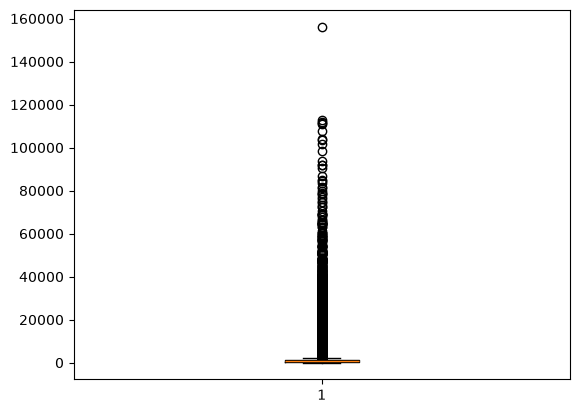

In [14]:
#get the avg stats of the text samples
tokens = list(fw['token_count'])
plt.boxplot(tokens)

In [15]:
mean_tok = np.mean(tokens)
mean_tok

np.float64(1039.7695867768596)

In [16]:
#Init a T5 encoder and a Diffusion Decoder. Perform Attention Pooling to transmit 512*1*Batch_Size
t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")
PAD_ID = t5_tokenizer.pad_token_id

In [17]:
from torch.utils.data import Dataset, DataLoader

class FineWebDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len,pad_id):
        """
        Args:
            texts (list or np.array): List of target text sequences.
            tokenizer: Hugging Face tokenizer instance.
            max_len (int): The exact fixed canvas length required by the denoiser.
        """
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.pad_id = pad_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
    
        # If your tokenizer doesn't have a pad token set by default, set it here:
        if self.tokenizer.pad_token_id is None and hasattr(self, 'pad_id'):
            self.tokenizer.pad_token_id = self.pad_id
    
        # Tokenize with explicit padding strategy
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',     # <--- Use 'max_length' here!
            max_length=self.max_len,   # <--- Pass your max sequence length here
            return_attention_mask=True,
            return_tensors='pt'
        )
    
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

In [18]:
fw_train = FineWebDataset(train,t5_tokenizer,32,PAD_ID)
fw_test = FineWebDataset(test,t5_tokenizer,32,PAD_ID)

In [22]:
def cycle(dataloader):
    """Generates an infinite stream of batches from a DataLoader."""
    while True:
        for batch in dataloader:
            yield batch

# --- Setup ---
train_loader = DataLoader(fw_train, batch_size=32, shuffle=True)
train_iter = cycle(train_loader)

test_loader = DataLoader(fw_test, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
# for batch in train_loader:
#     input_ids = batch['input_ids']           # Shape: [batch_size, 64]
#     attention_mask = batch['attention_mask'] # Shape: [batch_size, 64]

#     print("Batch shape:", input_ids.shape)
#     # Token IDs at the end will be filled with tokenizer.pad_token_id (e.g., 0)
#     print("First sequence sample:", input_ids[0])
#     break

In [24]:
#Physical Channels
class Channels():
    def AWGN(self, Tx_sig, n_var):
        Rx_sig = Tx_sig + torch.randn_like(Tx_sig) * n_var
        return Rx_sig

    def Rayleigh(self, Tx_sig, n_var):
        shape = Tx_sig.shape                       # [B, L, D]
        B, device = shape[0], Tx_sig.device

        # Per-example fading coefficients (was: one scalar H shared by whole batch)
        H_real = torch.normal(0, math.sqrt(1 / 2), size=(B,), device=device)
        H_imag = torch.normal(0, math.sqrt(1 / 2), size=(B,), device=device)
        H = torch.stack([
            torch.stack([H_real, -H_imag], dim=-1),
            torch.stack([H_imag,  H_real], dim=-1),
        ], dim=-2)                                  # [B, 2, 2]

        Tx_pairs = Tx_sig.reshape(B, -1, 2)          # [B, L*D/2, 2]
        Tx_faded = torch.bmm(Tx_pairs, H)            # [B, L*D/2, 2]
        Rx_faded = self.AWGN(Tx_faded, n_var)        # n_var: [B,1,1] broadcasts fine
        Rx_sig   = torch.bmm(Rx_faded, torch.inverse(H)).reshape(shape)
        return Rx_sig

    def Rician(self, Tx_sig, n_var, K=1):
        shape = Tx_sig.shape
        B, device = shape[0], Tx_sig.device
        mean = math.sqrt(K / (K + 1))
        std  = math.sqrt(1 / (K + 1))

        H_real = torch.normal(mean, std, size=(B,), device=device)
        H_imag = torch.normal(mean, std, size=(B,), device=device)
        H = torch.stack([
            torch.stack([H_real, -H_imag], dim=-1),
            torch.stack([H_imag,  H_real], dim=-1),
        ], dim=-2)                                  # [B, 2, 2]

        Tx_pairs = Tx_sig.reshape(B, -1, 2)
        Tx_faded = torch.bmm(Tx_pairs, H)
        Rx_faded = self.AWGN(Tx_faded, n_var)
        Rx_sig   = torch.bmm(Rx_faded, torch.inverse(H)).reshape(shape)
        return Rx_sig

    def forward(self, Tx_sig, n_var, channel_type="AWGN", K=1):
        if channel_type == "AWGN":
            return self.AWGN(Tx_sig, n_var)
        elif channel_type == "Rayleigh":
            return self.Rayleigh(Tx_sig, n_var)
        elif channel_type == "Rician":
            return self.Rician(Tx_sig, n_var, K=K)
        elif channel_type is None or channel_type == "None":
            return Tx_sig
        else:
            raise ValueError(f"Unknown channel_type: {channel_type}")


In [25]:
#use the T5 small encoder to acheive a batch*seq_len_512 embedding
class T5TextEncoder(nn.Module):
    def __init__(self, model_name: str = "t5-small"):
        super().__init__()
        self.t5_encoder = T5EncoderModel.from_pretrained(model_name)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Input:
            input_ids: (batch_size, 512)
            attention_mask: (batch_size, 512)
        Returns:
            last_hidden_state: (batch_size, 512, 512)
        """
        outputs = self.t5_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        return outputs.last_hidden_state

In [26]:
#From batch*seq_len*512 to batch*K=num_queries=8*d_chann=64
class TextQFormer(nn.Module):
    def __init__(
        self,
        d_model: int = 512,
        num_queries: int = 8,
        d_chan: int = 64,
        n_layers: int = 2,
        n_heads: int = 8,
        d_ff: int = 2048,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_queries = num_queries
        self.d_model = d_model
        
        # 1. Learnable query vectors initialized in d_model space: (1, K, 512)
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, d_model) * 0.02)
        
        # 2. Q-Former Stack using PyTorch's TransformerDecoder
        # (Handles Self-Attn among queries -> Cross-Attn over T5 outputs -> FFN)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.qformer = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        
        # 3. Optional projection layer to physical channel dimension (e.g., 512 -> 64)
        self.to_channel = nn.Linear(d_model, d_chan) if d_chan != d_model else nn.Identity()

    def forward(
        self, 
        x_t5: torch.Tensor, 
        attention_mask: torch.Tensor = None,
        power_normalize: bool = True
    ) -> torch.Tensor:
        """
        Input:
            x_t5: (batch_size, seq_len, 512) - T5 encoder output
            attention_mask: (batch_size, seq_len) - 1 for valid tokens, 0 for padding
            power_normalize: bool - whether to apply JSCC unit transmit power scaling

        Returns:
            z_chan: (batch_size, num_queries, d_chan) - Compressed latent ready for physical channel
        """
        B, L, _ = x_t5.shape
        
        # Expand queries for the batch: (B, K, 512)
        queries = self.query_tokens.repeat(B, 1, 1)
        
        # PyTorch TransformerDecoder expects True for padded/ignored positions
        memory_key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        
        # Process queries: Query = queries (tgt), Key/Value = x_t5 (memory)
        q_out = self.qformer(
            tgt=queries,
            memory=x_t5,
            memory_key_padding_mask=memory_key_padding_mask
        )  # Shape: (B, K, 512)
        
        # Project to target physical channel dimension: (B, K, d_chan)
        z_chan = self.to_channel(q_out)
        
        # Physical JSCC Power Normalization (E[||z||^2] = 1.0)
        if power_normalize:
            power = torch.mean(z_chan ** 2, dim=(-2, -1), keepdim=True)
            z_chan = z_chan / torch.sqrt(power + 1e-6)
            
        return z_chan

In [27]:
class DiffusionDecoder(nn.Module):
    def __init__(self, d_model=512, d_chan=64, n_heads=8, n_layers=4, diffusion_steps=128, n_snr_bins=19):
        super().__init__()
        self.chan_to_model = nn.Linear(d_chan, d_model) if d_chan != d_model else nn.Identity()
        self.time_emb = nn.Embedding(diffusion_steps + 1, d_model)
        self.snr_emb = nn.Embedding(n_snr_bins, d_model)
        self.pos_emb = nn.Embedding(512, d_model)  # Accommodates sequence lengths up to 512
        
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=2048,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True
        )
        self.denoiser = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, z_t, z_chan_rx, t, snr_bin, attention_mask=None):
        B, L, _ = z_t.shape
        t_embed = self.time_emb(t).unsqueeze(1)          # [B, 1, 512]
        s_embed = self.snr_emb(snr_bin).unsqueeze(1)        # [B, 1, 512]
        pos     = torch.arange(L, device=z_t.device).unsqueeze(0)
        p_embed = self.pos_emb(pos)                         # [1, L, 512]

        tgt = z_t + t_embed + s_embed + p_embed
        memory = self.chan_to_model(z_chan_rx) + s_embed    # [B, K, 512]
        
        tgt_key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        
        z0_hat = self.denoiser(tgt=tgt, memory=memory, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.ln_f(z0_hat)

In [28]:
class DeepSCDiffusionPipeline(nn.Module):
    def __init__(self, vocab_size=32128, num_queries=8, d_chan=64, diffusion_steps=128):
        super().__init__()
        self.vocab_size = vocab_size
        self.qformer    = TextQFormer(num_queries=num_queries, d_chan=d_chan)
        self.channel    = Channels()
        self.decoder    = DiffusionDecoder(d_chan=d_chan, diffusion_steps=diffusion_steps)
        self.lm_head    = nn.Linear(512, vocab_size, bias=False)
        
        steps = torch.arange(diffusion_steps + 1).float() / diffusion_steps
        sigmas = 0.002 * (1.0 / 0.002) ** steps
        self.register_buffer("sigmas", sigmas)

    def forward_loss(self, x_t5, input_ids, attention_mask, channel_type="Rayleigh", lambda_ce=0.1, snr_gamma=5.0):
        device = x_t5.device
        B = x_t5.size(0)

        # 1. Random Channel SNR Injection (0..18 dB)
        snr_db = torch.empty(B, device=device).uniform_(0, 18)
        snr_linear = 10 ** (snr_db / 10)
        noise_stds = (1.0 / (2.0 * snr_linear).sqrt()).view(-1, 1, 1)
        snr_bin = snr_db.long().clamp(0, 18)

        # 2. Q-Former Compression & Transmission
        z_chan = self.qformer(x_t5, attention_mask)
        z_chan_rx = self.channel.forward(z_chan, noise_stds, channel_type=channel_type)

        # 3. Add Diffusion Noise to T5 Embeddings (x_t5)
        t = torch.randint(1, len(self.sigmas) - 1, (B,), device=device)
        sigma_t = self.sigmas[t].view(-1, 1, 1)
        z_t = x_t5 + torch.randn_like(x_t5) * sigma_t

        # 4. Cross-Attention Denoising
        x_t5_hat = self.decoder(z_t, z_chan_rx, t, snr_bin, attention_mask)

        # 5. Min-SNR Gamma Weighted MSE Loss
        snr_t = 1.0 / sigma_t.clamp_min(1e-6) ** 2
        weight_t = snr_t.clamp(max=snr_gamma) / snr_t
        mask = attention_mask.unsqueeze(-1).float()
        
        per_token_mse = ((x_t5_hat - x_t5) ** 2).mean(dim=-1, keepdim=True)
        denom = (weight_t * mask).sum().clamp_min(1)
        mse_loss = (per_token_mse * weight_t * mask).sum() / denom

        # 6. Auxiliary Cross-Entropy Loss
        targets = input_ids.clone()
        targets[attention_mask == 0] = -100
        logits = self.lm_head(x_t5_hat)
        # Mask target token IDs exceeding vocabulary bounds
        targets = input_ids.clone()
        targets[attention_mask == 0] = -100
        targets[targets >= self.vocab_size] = -100
        
        ce_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
        
        # FIX 3: Set lambda_ce = 1.0 (or pass lambda_ce=1.0 in loop)
        total_loss = mse_loss + lambda_ce * ce_loss
        return total_loss, mse_loss.item(), ce_loss.item()

In [29]:
@torch.no_grad()
def generate_from_channel(model, z_chan_rx, seq_len, snr_bin, attention_mask=None, n_steps=10):
    B = z_chan_rx.size(0)
    device = z_chan_rx.device
    num_timesteps = len(model.sigmas) - 1
    
    # Start from pure noise scaled by sigma_max
    sigma_max = model.sigmas[-1].item()
    z_t = torch.randn(B, seq_len, 512, device=device) * sigma_max
    
    ts = torch.linspace(num_timesteps, 1, n_steps, device=device).long()
    
    for i in range(n_steps):
        t_cur = ts[i].expand(B)
        sigma_cur = model.sigmas[t_cur].view(-1, 1, 1)
        
        x0_hat = model.decoder(z_t, z_chan_rx, t_cur, snr_bin, attention_mask)
        
        if i == n_steps - 1:
            z_t = x0_hat
            break
            
        t_next = ts[i + 1].expand(B)
        sigma_next = model.sigmas[t_next].view(-1, 1, 1)
        
        direction = (z_t - x0_hat) / sigma_cur.clamp_min(1e-5)
        z_t = x0_hat + sigma_next * direction

    # FIX 1: Remove / math.sqrt(512) here!
    logits = model.lm_head(z_t)
    pred_ids = logits.argmax(dim=-1)
    return pred_ids

In [ ]:
def cycle(dataloader):
    """Infinite iterator wrapper for step-based training loops."""
    while True:
        for batch in dataloader:
            yield batch


@torch.no_grad()
def run_sanity_check(
    model, 
    encoder, 
    batch, 
    t5_tokenizer, 
    device, 
    step, 
    eval_snr_db=12.0, 
    num_samples=2
):
    """Performs DDIM reverse sampling on a small batch subset for inline logging."""
    model.eval()
    
    input_ids = batch['input_ids'][:num_samples].to(device)
    attention_mask = batch['attention_mask'][:num_samples].to(device)
    
    # 1. Get ground truth T5 embeddings
    embeddings = encoder(input_ids=input_ids, attention_mask=attention_mask)
    
    # 2. Simulate Channel Transmission at target SNR
    snr_tensor = torch.tensor([eval_snr_db], device=device).repeat(input_ids.size(0))
    snr_linear = 10 ** (snr_tensor / 10)
    noise_std = (1.0 / (2.0 * snr_linear).sqrt()).view(-1, 1, 1)
    snr_bin = snr_tensor.long().clamp(0, 18)
    
    # 3. Compress & Transmit through physical channel
    z_chan = model.qformer(embeddings, attention_mask)
    z_chan_rx = model.channel.forward(z_chan, noise_std, channel_type="Rayleigh")
    
    # 4. DDIM Generation (10 reverse steps)
    pred_ids = generate_from_channel(
        model=model,
        z_chan_rx=z_chan_rx,
        seq_len=input_ids.size(1),
        snr_bin=snr_bin,
        attention_mask=attention_mask,
        n_steps=10
    )
    
    # Decode text output
    gt_text = t5_tokenizer.batch_decode(input_ids, skip_special_tokens=True)
    pred_text = t5_tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    
    print("\n" + "=" * 60)
    print(f"  [SANITY CHECK @ Step {step:05d} | {eval_snr_db:.0f} dB Rayleigh Channel]")
    print("=" * 60)
    for idx in range(input_ids.size(0)):
        print(f"  [Sample {idx+1}]")
        print(f"  GT  : {gt_text[idx]}")
        print(f"  PRED: {pred_text[idx]}\n")
    print("=" * 60 + "\n")
    
    model.train()


# =============================================================================
# MAIN TRAINING SETUP & LOOP
# =============================================================================

# Device & Model Initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = T5TextEncoder().to(device)
encoder.eval()

model = DeepSCDiffusionPipeline(
    vocab_size=len(t5_tokenizer), 
    num_queries=8, 
    d_chan=64
).to(device)

# Optimization Setup
total_steps = 50_000
log_interval = 50
eval_interval = 250

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)

# Infinite DataLoader Stream
train_iter = cycle(train_loader)

print("Starting Diffusion Semantic Communication Training...")
model.train()

for step in range(1, total_steps + 1):
    batch = next(train_iter)
    
    input_ids = batch['input_ids'].to(device)         # [B, L]
    attention_mask = batch['attention_mask'].to(device) # [B, L]
    
    # 1. Ground-truth T5 sequence embeddings
    with torch.no_grad():
        embeddings = encoder(input_ids=input_ids, attention_mask=attention_mask)  # [B, L, 512]
    
    # 2. Forward pass & loss calculation
    optimizer.zero_grad()
    loss, mse_val, ce_val = model.forward_loss(
        x_t5=embeddings,
        input_ids=input_ids,
        attention_mask=attention_mask,
        channel_type="Rayleigh"
    )
    
    # 3. Backpropagation & Optimization Step
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    
    # 4. Step-based Logging
    if step % log_interval == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Step {step:05d}/{total_steps} | "
            f"Loss: {loss.item():.4f} | "
            f"MSE: {mse_val:.4f} | "
            f"CE: {ce_val:.4f} | "
            f"LR: {current_lr:.2e}"
        )
    
    # 5. Inline Sanity Check Evaluation
    if step % eval_interval == 0:
        run_sanity_check(
            model=model,
            encoder=encoder,
            batch=batch,
            t5_tokenizer=t5_tokenizer,
            device=device,
            step=step,
            eval_snr_db=12.0
        )

print("Training Completed Successfully!")

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 8151.11it/s]


Starting Diffusion Semantic Communication Training...
Step 00050/50000 | Loss: 1.5308 | MSE: 0.9162 | CE: 6.1455 | LR: 2.00e-04
Step 00100/50000 | Loss: 1.4594 | MSE: 0.8634 | CE: 5.9595 | LR: 2.00e-04
Step 00150/50000 | Loss: 1.4144 | MSE: 0.8256 | CE: 5.8879 | LR: 2.00e-04
Step 00200/50000 | Loss: 1.3405 | MSE: 0.7954 | CE: 5.4506 | LR: 2.00e-04
Step 00250/50000 | Loss: 1.3190 | MSE: 0.7665 | CE: 5.5246 | LR: 2.00e-04

  [SANITY CHECK @ Step 00250 | 12 dB Rayleigh Channel]
  [Sample 1]
  GT  : the second point is the question of how far statistical requirements can be reduced to a minimum. the commission has approved this too.
  PRED: m     the            to  to      and 

  [Sample 2]
  GT  : the conciliation committee is presenting a package of anti pollution measures today which involves a series of important economic consequences.
  PRED: m      to      the        to     


Step 00300/50000 | Loss: 1.2495 | MSE: 0.7368 | CE: 5.1271 | LR: 2.00e-04
Step 00350/50000 | Loss: 1.1969 |